In [161]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler


In [2]:
# Read the same raw file EDA used
df = pd.read_csv("../data/processed/laps_2023.csv")

print("Shape of the dataset:", df.shape)

Shape of the dataset: (11255, 33)


In [3]:
pd.set_option("display.max_columns", None)
df.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,RaceName,Year
0,0 days 01:04:15.902000,VER,1,0 days 00:01:39.019000,1.0,1.0,NaN,NaN,NaN,0 days 00:00:42.414000,0 days 00:00:23.842000,NaN,0 days 01:03:52.119000,0 days 01:04:16.010000,232.0,231.0,278.0,252.0,False,SOFT,4.0,False,Red Bull Racing,0 days 01:02:36.652000,NaN,12,1.0,NaN,NaN,False,False,Bahrain,2023
1,0 days 01:05:53.876000,VER,1,0 days 00:01:37.974000,2.0,1.0,NaN,NaN,0 days 00:00:31.342000,0 days 00:00:42.504000,0 days 00:00:24.128000,0 days 01:04:47.303000,0 days 01:05:29.807000,0 days 01:05:53.935000,227.0,238.0,278.0,288.0,True,SOFT,5.0,False,Red Bull Racing,0 days 01:04:15.902000,NaN,12,1.0,NaN,NaN,False,True,Bahrain,2023
2,0 days 01:07:31.882000,VER,1,0 days 00:01:38.006000,3.0,1.0,NaN,NaN,0 days 00:00:31.388000,0 days 00:00:42.469000,0 days 00:00:24.149000,0 days 01:06:25.323000,0 days 01:07:07.792000,0 days 01:07:31.941000,227.0,238.0,278.0,287.0,False,SOFT,6.0,False,Red Bull Racing,0 days 01:05:53.876000,NaN,1,1.0,NaN,NaN,False,True,Bahrain,2023
3,0 days 01:09:09.858000,VER,1,0 days 00:01:37.976000,4.0,1.0,NaN,NaN,0 days 00:00:31.271000,0 days 00:00:42.642000,0 days 00:00:24.063000,0 days 01:08:03.212000,0 days 01:08:45.854000,0 days 01:09:09.917000,228.0,238.0,278.0,289.0,False,SOFT,7.0,False,Red Bull Racing,0 days 01:07:31.882000,NaN,1,1.0,NaN,NaN,False,True,Bahrain,2023
4,0 days 01:10:47.893000,VER,1,0 days 00:01:38.035000,5.0,1.0,NaN,NaN,0 days 00:00:31.244000,0 days 00:00:42.724000,0 days 00:00:24.067000,0 days 01:09:41.161000,0 days 01:10:23.885000,0 days 01:10:47.952000,228.0,239.0,278.0,290.0,False,SOFT,8.0,False,Red Bull Racing,0 days 01:09:09.858000,NaN,1,1.0,NaN,NaN,False,True,Bahrain,2023


In [4]:
# Drop useless columns (100% missing)
df.drop(columns = ["LapStartDate", "Deleted", "DeletedReason"], inplace = True)
df.head()


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,TrackStatus,Position,FastF1Generated,IsAccurate,RaceName,Year
0,0 days 01:04:15.902000,VER,1,0 days 00:01:39.019000,1.0,1.0,NaN,NaN,NaN,0 days 00:00:42.414000,0 days 00:00:23.842000,NaN,0 days 01:03:52.119000,0 days 01:04:16.010000,232.0,231.0,278.0,252.0,False,SOFT,4.0,False,Red Bull Racing,0 days 01:02:36.652000,12,1.0,False,False,Bahrain,2023
1,0 days 01:05:53.876000,VER,1,0 days 00:01:37.974000,2.0,1.0,NaN,NaN,0 days 00:00:31.342000,0 days 00:00:42.504000,0 days 00:00:24.128000,0 days 01:04:47.303000,0 days 01:05:29.807000,0 days 01:05:53.935000,227.0,238.0,278.0,288.0,True,SOFT,5.0,False,Red Bull Racing,0 days 01:04:15.902000,12,1.0,False,True,Bahrain,2023
2,0 days 01:07:31.882000,VER,1,0 days 00:01:38.006000,3.0,1.0,NaN,NaN,0 days 00:00:31.388000,0 days 00:00:42.469000,0 days 00:00:24.149000,0 days 01:06:25.323000,0 days 01:07:07.792000,0 days 01:07:31.941000,227.0,238.0,278.0,287.0,False,SOFT,6.0,False,Red Bull Racing,0 days 01:05:53.876000,1,1.0,False,True,Bahrain,2023
3,0 days 01:09:09.858000,VER,1,0 days 00:01:37.976000,4.0,1.0,NaN,NaN,0 days 00:00:31.271000,0 days 00:00:42.642000,0 days 00:00:24.063000,0 days 01:08:03.212000,0 days 01:08:45.854000,0 days 01:09:09.917000,228.0,238.0,278.0,289.0,False,SOFT,7.0,False,Red Bull Racing,0 days 01:07:31.882000,1,1.0,False,True,Bahrain,2023
4,0 days 01:10:47.893000,VER,1,0 days 00:01:38.035000,5.0,1.0,NaN,NaN,0 days 00:00:31.244000,0 days 00:00:42.724000,0 days 00:00:24.067000,0 days 01:09:41.161000,0 days 01:10:23.885000,0 days 01:10:47.952000,228.0,239.0,278.0,290.0,False,SOFT,8.0,False,Red Bull Racing,0 days 01:09:09.858000,1,1.0,False,True,Bahrain,2023


In [5]:
df.shape

(11255, 30)

#### Features with 100% missing values were dropped cause it carries zero information

---------------------------------------------------------------

In [8]:
# Time related columns 
time_col = [feature for feature in df.columns if ("Time" in feature) or ("Date" in feature)]
print(time_col)

df[time_col].head(10)

['Time', 'LapTime', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'LapStartTime']


,Time,LapTime,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,LapStartTime
0,0 days 01:04:15.902000,0 days 00:01:39.019000,NaN,NaN,NaN,0 days 00:00:42.414000,0 days 00:00:23.842000,NaN,0 days 01:03:52.119000,0 days 01:04:16.010000,0 days 01:02:36.652000
1,0 days 01:05:53.876000,0 days 00:01:37.974000,NaN,NaN,0 days 00:00:31.342000,0 days 00:00:42.504000,0 days 00:00:24.128000,0 days 01:04:47.303000,0 days 01:05:29.807000,0 days 01:05:53.935000,0 days 01:04:15.902000
2,0 days 01:07:31.882000,0 days 00:01:38.006000,NaN,NaN,0 days 00:00:31.388000,0 days 00:00:42.469000,0 days 00:00:24.149000,0 days 01:06:25.323000,0 days 01:07:07.792000,0 days 01:07:31.941000,0 days 01:05:53.876000
3,0 days 01:09:09.858000,0 days 00:01:37.976000,NaN,NaN,0 days 00:00:31.271000,0 days 00:00:42.642000,0 days 00:00:24.063000,0 days 01:08:03.212000,0 days 01:08:45.854000,0 days 01:09:09.917000,0 days 01:07:31.882000
4,0 days 01:10:47.893000,0 days 00:01:38.035000,NaN,NaN,0 days 00:00:31.244000,0 days 00:00:42.724000,0 days 00:00:24.067000,0 days 01:09:41.161000,0 days 01:10:23.885000,0 days 01:10:47.952000,0 days 01:09:09.858000
5,0 days 01:12:25.879000,0 days 00:01:37.986000,NaN,NaN,0 days 00:00:31.341000,0 days 00:00:42.632000,0 days 00:00:24.013000,0 days 01:11:19.293000,0 days 01:12:01.925000,0 days 01:12:25.938000,0 days 01:10:47.893000
6,0 days 01:14:03.900000,0 days 00:01:38.021000,NaN,NaN,0 days 00:00:31.290000,0 days 00:00:42.763000,0 days 00:00:23.968000,0 days 01:12:57.228000,0 days 01:13:39.991000,0 days 01:14:03.959000,0 days 01:12:25.879000
7,0 days 01:15:42.054000,0 days 00:01:38.154000,NaN,NaN,0 days 00:00:31.291000,0 days 00:00:42.833000,0 days 00:00:24.030000,0 days 01:14:35.250000,0 days 01:15:18.083000,0 days 01:15:42.113000,0 days 01:14:03.900000
8,0 days 01:17:20.332000,0 days 00:01:38.278000,NaN,NaN,0 days 00:00:31.336000,0 days 00:00:42.823000,0 days 00:00:24.119000,0 days 01:16:13.449000,0 days 01:16:56.272000,0 days 01:17:20.391000,0 days 01:15:42.054000
9,0 days 01:18:58.701000,0 days 00:01:38.369000,NaN,NaN,0 days 00:00:31.361000,0 days 00:00:42.884000,0 days 00:00:24.124000,0 days 01:17:51.752000,0 days 01:18:34.636000,0 days 01:18:58.760000,0 days 01:17:20.332000


In [9]:
# Convert timedelta ----> seconds


# Strip column name incase of hidden space
df.columns = df.columns.str.strip()

for col in time_col:
    df[col]= pd.to_timedelta(df[col], errors = "coerce").dt.total_seconds()

df[time_col].head()

,Time,LapTime,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,LapStartTime
0,3855.902,99.019,NaN,NaN,NaN,42.414,23.842,NaN,3832.119,3856.010,3756.652
1,3953.876,97.974,NaN,NaN,31.342,42.504,24.128,3887.303,3929.807,3953.935,3855.902
2,4051.882,98.006,NaN,NaN,31.388,42.469,24.149,3985.323,4027.792,4051.941,3953.876
3,4149.858,97.976,NaN,NaN,31.271,42.642,24.063,4083.212,4125.854,4149.917,4051.882
4,4247.893,98.035,NaN,NaN,31.244,42.724,24.067,4181.161,4223.885,4247.952,4149.858


In [10]:
print(df[time_col].dtypes)

Time                  float64
LapTime               float64
PitOutTime            float64
PitInTime             float64
Sector1Time           float64
Sector2Time           float64
Sector3Time           float64
Sector1SessionTime    float64
Sector2SessionTime    float64
Sector3SessionTime    float64
LapStartTime          float64
dtype: object


--------

In [12]:
# Fix categorical vs numerical cols
categorical_numeric = ["DriverNumber", "Year", "Position", "TrackStatus"]

print(df[categorical_numeric].dtypes, "\n\n")


for col in categorical_numeric:
    df[col] = df[col].astype("category")

print(df[categorical_numeric].dtypes, "\n")

DriverNumber      int64
Year              int64
Position        float64
TrackStatus       int64
dtype: object 


DriverNumber    category
Year            category
Position        category
TrackStatus     category
dtype: object 



In [13]:
# Fix boolean cols
bool_cols = [feature for feature in df.columns if df[feature].dtype == "bool"]

print(bool_cols, "\n")

# IsPersonalBest is a bool value but stored as an object 
bool_cols.append("IsPersonalBest")
print(bool_cols, "\n\n")


for col in bool_cols:
    df[col] = df[col].map({
        True: True,
        False: False,
        "True": True, 
        "False": False,
        None: pd.NA,
        "nan": pd.NA
    })
    df[col] = df[col].astype("bool")




print(df[bool_cols].head())
print(df[bool_cols].dtypes)

['FreshTyre', 'FastF1Generated', 'IsAccurate'] 

['FreshTyre', 'FastF1Generated', 'IsAccurate', 'IsPersonalBest'] 


   FreshTyre  FastF1Generated  IsAccurate  IsPersonalBest
0      False            False       False           False
1      False            False        True            True
2      False            False        True           False
3      False            False        True           False
4      False            False        True           False
FreshTyre          bool
FastF1Generated    bool
IsAccurate         bool
IsPersonalBest     bool
dtype: object


---------

In [15]:
# Create Target Variable 

# PitInTime contains the time a driver entered the pit lane
# If PitInTime has a value = driver pitted that lap = 1
# If PitInTime is NaN = driver stayed out = 0

df["Pitted"] = df["PitInTime"].notna().astype(int)

print("Pit stop distribution:")
print(df["Pitted"].value_counts())
print(f"\nPit Stop rate: {df['Pitted'].mean():.2f}")

Pit stop distribution:
Pitted
0    10878
1      377
Name: count, dtype: int64

Pit Stop rate: 0.03


In [16]:
# Drop PitInTime and PitOutTime
# We already extracted the signal we need (Pitted column)
# Model must never see these 

df.drop(columns = ["PitInTime", "PitOutTime"], inplace = True)
# inplace = True modifys the existing dataframe directly instead of creating a new one

print("Columns remaining:", df.shape[1])

Columns remaining: 29


In [17]:
df.shape

(11255, 29)

In [18]:
df.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,TrackStatus,Position,FastF1Generated,IsAccurate,RaceName,Year,Pitted
0,3855.902,VER,1,99.019,1.0,1.0,NaN,42.414,23.842,NaN,3832.119,3856.010,232.0,231.0,278.0,252.0,False,SOFT,4.0,False,Red Bull Racing,3756.652,12,1.0,False,False,Bahrain,2023,0
1,3953.876,VER,1,97.974,2.0,1.0,31.342,42.504,24.128,3887.303,3929.807,3953.935,227.0,238.0,278.0,288.0,True,SOFT,5.0,False,Red Bull Racing,3855.902,12,1.0,False,True,Bahrain,2023,0
2,4051.882,VER,1,98.006,3.0,1.0,31.388,42.469,24.149,3985.323,4027.792,4051.941,227.0,238.0,278.0,287.0,False,SOFT,6.0,False,Red Bull Racing,3953.876,1,1.0,False,True,Bahrain,2023,0
3,4149.858,VER,1,97.976,4.0,1.0,31.271,42.642,24.063,4083.212,4125.854,4149.917,228.0,238.0,278.0,289.0,False,SOFT,7.0,False,Red Bull Racing,4051.882,1,1.0,False,True,Bahrain,2023,0
4,4247.893,VER,1,98.035,5.0,1.0,31.244,42.724,24.067,4181.161,4223.885,4247.952,228.0,239.0,278.0,290.0,False,SOFT,8.0,False,Red Bull Racing,4149.858,1,1.0,False,True,Bahrain,2023,0


---

#### Encode Tyre Compounds
#### We encode by durability - how long each compound lasts

```
SOFT = 0 ---> degrades fastest 
MEDIUM = 1 ---> middle 
HARD = 2 ---> most durable 
INTERMEDIATE = 3 --> wet conditions
WET = 4 --> full wet

```

In [21]:
# Map each compound to a number 

compound_map = {
    "SOFT": 0,
    "MEDIUM": 1, 
    "HARD": 2, 
    "INTERMEDIATE": 3, 
    "WET" : 4
}

df["CompoundEncoded"] = df["Compound"].map(compound_map)

# Check for any compounds we missed 
print("Unmapped compounds:", df[df["CompoundEncoded"].isna()]["Compound"].unique())


# Confirm distribution 
print("\nCompound distribution")
print(df.groupby("Compound")["CompoundEncoded"].first())

Unmapped compounds: []

Compound distribution
Compound
HARD            2
INTERMEDIATE    3
MEDIUM          1
SOFT            0
WET             4
Name: CompoundEncoded, dtype: int64


In [22]:
df.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,TrackStatus,Position,FastF1Generated,IsAccurate,RaceName,Year,Pitted,CompoundEncoded
0,3855.902,VER,1,99.019,1.0,1.0,NaN,42.414,23.842,NaN,3832.119,3856.010,232.0,231.0,278.0,252.0,False,SOFT,4.0,False,Red Bull Racing,3756.652,12,1.0,False,False,Bahrain,2023,0,0
1,3953.876,VER,1,97.974,2.0,1.0,31.342,42.504,24.128,3887.303,3929.807,3953.935,227.0,238.0,278.0,288.0,True,SOFT,5.0,False,Red Bull Racing,3855.902,12,1.0,False,True,Bahrain,2023,0,0
2,4051.882,VER,1,98.006,3.0,1.0,31.388,42.469,24.149,3985.323,4027.792,4051.941,227.0,238.0,278.0,287.0,False,SOFT,6.0,False,Red Bull Racing,3953.876,1,1.0,False,True,Bahrain,2023,0,0
3,4149.858,VER,1,97.976,4.0,1.0,31.271,42.642,24.063,4083.212,4125.854,4149.917,228.0,238.0,278.0,289.0,False,SOFT,7.0,False,Red Bull Racing,4051.882,1,1.0,False,True,Bahrain,2023,0,0
4,4247.893,VER,1,98.035,5.0,1.0,31.244,42.724,24.067,4181.161,4223.885,4247.952,228.0,239.0,278.0,290.0,False,SOFT,8.0,False,Red Bull Racing,4149.858,1,1.0,False,True,Bahrain,2023,0,0


-----

In [24]:
# Tyre Degradation Features 
# Features that tell the model what's happening to the tyres RIGHT NOW


# Sort by race -> driver -> stint -> lap number 
# This ensures laps are in chronological order 
# per driver per stint

df = df.sort_values(
    ["RaceName", "Driver", "Stint", "LapNumber"]
).reset_index(drop = True)

print("Data sorted correctly")
df[["RaceName", "Driver", "Stint", "LapNumber", "LapTime"]].head()



Data sorted correctly


,RaceName,Driver,Stint,LapNumber,LapTime
0,Abu Dhabi,ALB,1.0,1.0,100.625
1,Abu Dhabi,ALB,1.0,2.0,93.560
2,Abu Dhabi,ALB,1.0,3.0,91.768
3,Abu Dhabi,ALB,1.0,4.0,91.591
4,Abu Dhabi,ALB,1.0,5.0,91.422


In [25]:
# Lap 1: 100.6s <- slow, just started, cold tyres
# Lap 2: 93.6s <- much faster, tyres warming up
# Lap 3: 91.7s <- getting faster 
# Lap 4: 91.5s <- peak performance
# Lap 5: 91.4s <- still near peak 


# Tyres start cold, warm up, peak, then slowly degrade.

#### Tyre Degradation features 

```
Why we are builiding these features:
the raw data only tells us:

TyreLife = 21
LapTime = 92.3s

But the model needs to understand what's happening over time.
- Is the tyre getting slower?
- How much slower vs when it was new?
- Is the degradation speeding up?

A single lap time number doesn't tell us that. so we need to compare it to previous laps. 
```
##### 1. FEATURE 1: LapTimeDelta

In [27]:
# LapTimeDelta 
# How much slower is this lap compared to the previous lap?
# Captures : is the tyre degrading RIGHT NOW?

#.diff() calculates the difference between current row and the previous row 
# We group by Race + Driver + Stint so we don't calculate delta across different stints or different drivers


# Positive = getting slower = tyre degrading 
# Negative = getting faster = tyre warming up

df["LapTimeDelta"] = df.groupby(
    ["RaceName", "Driver", "Stint"]
)["LapTime"].diff()

df[["RaceName", "Driver", "Stint", 
    "LapNumber", "LapTime", "LapTimeDelta"]].head(10)

,RaceName,Driver,Stint,LapNumber,LapTime,LapTimeDelta
0,Abu Dhabi,ALB,1.0,1.0,100.625,NaN
1,Abu Dhabi,ALB,1.0,2.0,93.560,-7.065
2,Abu Dhabi,ALB,1.0,3.0,91.768,-1.792
3,Abu Dhabi,ALB,1.0,4.0,91.591,-0.177
4,Abu Dhabi,ALB,1.0,5.0,91.422,-0.169
5,Abu Dhabi,ALB,1.0,6.0,91.491,0.069
6,Abu Dhabi,ALB,1.0,7.0,91.438,-0.053
7,Abu Dhabi,ALB,1.0,8.0,91.580,0.142
8,Abu Dhabi,ALB,1.0,9.0,91.644,0.064
9,Abu Dhabi,ALB,1.0,10.0,91.978,0.334


```
Lap 1: NaN ---> no previous lap to compare, expected
Lap 2: -7.065 --> 7 seconds faster than Lap 1 (tyre warming up)
Lap 3: -1.792 --> still getting faster
Lap 4: -0.177 --> nearly stabilized
Lap 5 - 10 : small fluctuations around 0


--- lap 1 is always slow(cold tyres, traffic from pit exit), then the car rapidly speeds up as tyres warm up, then it stabilizes.

```

##### 2. FEATURE 2: LapTimeRolling

In [30]:
# Average lap time over the LAST 3 laps
# Captures: what is the underlying pace right now?
# Why 3 laps: One bad lap could be traffic or a yellow flag, averaging 3 laps smooths out that noise

df["LapTimeRolling3"] = df.groupby(
    ["RaceName", "Driver", "Stint"]
)["LapTime"].transform(
    lambda x: x.rolling(window = 3, min_periods = 1).mean()

)

df[["Driver", "Stint", "LapNumber",
    "LapTime", "LapTimeRolling3"]].head(10)

,Driver,Stint,LapNumber,LapTime,LapTimeRolling3
0,ALB,1.0,1.0,100.625,100.625000
1,ALB,1.0,2.0,93.560,97.092500
2,ALB,1.0,3.0,91.768,95.317667
3,ALB,1.0,4.0,91.591,92.306333
4,ALB,1.0,5.0,91.422,91.593667
5,ALB,1.0,6.0,91.491,91.501333
6,ALB,1.0,7.0,91.438,91.450333
7,ALB,1.0,8.0,91.580,91.503000
8,ALB,1.0,9.0,91.644,91.554000
9,ALB,1.0,10.0,91.978,91.734000


```

Lap 1: 100.625 --> just lap 1 alone (only 1 data point so far)
Lap 2: 97.09 --> average of laps 1 - 2
Lap 3: 95.32 --> average of laps 1 - 3
Lap 4: 92.31 --> average of laps 2- 4 (rolling window of 3)

--- by lap 5 onwards it's hovering around 91.5, which matches the stabilized pace

```

##### 3. FEATURE 3: DegradationFromStintStart

In [33]:
# How much slower are we NOW vs lap 1 of this stint?
# Captures: TOTAL Performance loss on this tyre set 
# eg:  +3.2s means 3.2 seconds slower than when tyre was fresh

df["DegradationFromStintStart"] = df.groupby (
    ["RaceName", "Driver", "Stint"]
)["LapTime"].transform(
    lambda x: x - x.iloc[0]
)

df[["Driver", "Stint", "LapTime",
    "LapTime", "DegradationFromStintStart"]].head(10)

,Driver,Stint,LapTime,LapTime,DegradationFromStintStart
0,ALB,1.0,100.625,100.625,0.000
1,ALB,1.0,93.560,93.560,-7.065
2,ALB,1.0,91.768,91.768,-8.857
3,ALB,1.0,91.591,91.591,-9.034
4,ALB,1.0,91.422,91.422,-9.203
5,ALB,1.0,91.491,91.491,-9.134
6,ALB,1.0,91.438,91.438,-9.187
7,ALB,1.0,91.580,91.580,-9.045
8,ALB,1.0,91.644,91.644,-8.981
9,ALB,1.0,91.978,91.978,-8.647


```
Lap 1 was slow cause of the cold tyres, so every lap after looks "faster" relative to that slow start.

but this isn't capturing true degradation yet, we typically exclude the out-lap when measuring degradation and start the 'stint start' reference from lap 2 or 3 once the tyre has actually warmed up.
```

In [35]:
# Instead of comparing to lap 1 of the stint (which is artificially slow), compare to 
# lap 3 of the stint, by then the tyre has warmed up and we get a 
# true degradation baseline


def cal_degradation(group):
    # Use lap 3 as baseline if it exists, otherwise fall back to first available lap
    # This skips the slow out-lap(lap1) and warm-up lap (lap2)

    if len(group) >=3:
        baseline = group.iloc[2] #3rd lap of the stint
    else:
        baseline = group.iloc[0]

    return group - baseline



df["DegradationFromStintStart"] = df.groupby(
    ["RaceName", "Driver", "Stint"]
)["LapTime"].transform(cal_degradation)


df[df["Driver"] == "ALB"][["LapNumber", "LapTime", "DegradationFromStintStart"]].head(15)

,LapNumber,LapTime,DegradationFromStintStart
0,1.0,100.625,8.857
1,2.0,93.560,1.792
2,3.0,91.768,0.000
3,4.0,91.591,-0.177
4,5.0,91.422,-0.346
5,6.0,91.491,-0.277
6,7.0,91.438,-0.330
7,8.0,91.580,-0.188
8,9.0,91.644,-0.124
9,10.0,91.978,0.210


```
Laps 1-2   → warming up (slow → fast)
Laps 3-9   → peak performance window (fastest laps)
Laps 10+   → degradation creeping in (numbers trending positive)
```

In [37]:
df.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,TrackStatus,Position,FastF1Generated,IsAccurate,RaceName,Year,Pitted,CompoundEncoded,LapTimeDelta,LapTimeRolling3,DegradationFromStintStart
0,3845.400,ALB,23,100.625,1.0,1.0,NaN,40.189,35.489,NaN,3810.097,3845.518,287.0,287.0,211.0,289.0,False,MEDIUM,2.0,False,Williams,3744.519,1,17.0,False,False,Abu Dhabi,2023,0,1,NaN,100.625000,8.857
1,3938.960,ALB,23,93.560,2.0,1.0,18.892,39.357,35.311,3864.323,3903.680,3938.991,286.0,313.0,208.0,319.0,True,MEDIUM,3.0,False,Williams,3845.400,1,18.0,False,True,Abu Dhabi,2023,0,1,-7.065,97.092500,1.792
2,4030.728,ALB,23,91.768,3.0,1.0,18.588,38.312,34.868,3957.579,3995.891,4030.759,290.0,304.0,207.0,325.0,True,MEDIUM,4.0,False,Williams,3938.960,1,18.0,False,True,Abu Dhabi,2023,0,1,-1.792,95.317667,0.000
3,4122.319,ALB,23,91.591,4.0,1.0,18.657,38.211,34.723,4049.416,4087.627,4122.350,287.0,298.0,206.0,331.0,True,MEDIUM,5.0,False,Williams,4030.728,1,18.0,False,True,Abu Dhabi,2023,0,1,-0.177,92.306333,-0.177
4,4213.741,ALB,23,91.422,5.0,1.0,18.605,38.328,34.489,4140.955,4179.283,4213.772,286.0,319.0,205.0,327.0,True,MEDIUM,6.0,False,Williams,4122.319,1,18.0,False,True,Abu Dhabi,2023,0,1,-0.169,91.593667,-0.346


----

#### Race Context Features

In [40]:
# Drivers with multiple stints
# Check what happens to LapNumber vs TyreLife across a pit stop

sample_driver = df[df["Driver"] == "ALB"]
sample_driver[["LapNumber", "Stint", "TyreLife"]].head(30)

,LapNumber,Stint,TyreLife
0,1.0,1.0,2.0
1,2.0,1.0,3.0
2,3.0,1.0,4.0
3,4.0,1.0,5.0
4,5.0,1.0,6.0
5,6.0,1.0,7.0
6,7.0,1.0,8.0
7,8.0,1.0,9.0
8,9.0,1.0,10.0
9,10.0,1.0,11.0


#### Feature 1: RacePctComplete

```

- Races have different lengths. Monaco is 78 laps, Spa is 44 laps. If the model just sees
LapNumber = 40,
it doesn't know if that's early or late. 40 out of 78 is very different to 40 out of 44

by converting to a percentage, the model can compare across different races on the same scale. Lap 40 of 44 (91% done) means something totally different from lap 40 of 78(51% done)

``

In [43]:
# Creating TotalLaps 

# For each race, find the maximum LapNumber any driver reaches 

df["TotalLaps"] = df.groupby("RaceName")["LapNumber"].transform("max")

df[["RaceName", "LapNumber", "TotalLaps"]].head(10)

,RaceName,LapNumber,TotalLaps
0,Abu Dhabi,1.0,58.0
1,Abu Dhabi,2.0,58.0
2,Abu Dhabi,3.0,58.0
3,Abu Dhabi,4.0,58.0
4,Abu Dhabi,5.0,58.0
5,Abu Dhabi,6.0,58.0
6,Abu Dhabi,7.0,58.0
7,Abu Dhabi,8.0,58.0
8,Abu Dhabi,9.0,58.0
9,Abu Dhabi,10.0,58.0


In [44]:
df.groupby("RaceName")["TotalLaps"].unique()

RaceName
Abu Dhabi       [58.0]
Australia       [58.0]
Bahrain         [57.0]
Hungary         [70.0]
Monaco          [78.0]
Monza           [51.0]
Saudi Arabia    [50.0]
Silverstone     [52.0]
Singapore       [62.0]
Spain           [66.0]
Name: TotalLaps, dtype: object

In [45]:
df.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,TrackStatus,Position,FastF1Generated,IsAccurate,RaceName,Year,Pitted,CompoundEncoded,LapTimeDelta,LapTimeRolling3,DegradationFromStintStart,TotalLaps
0,3845.400,ALB,23,100.625,1.0,1.0,NaN,40.189,35.489,NaN,3810.097,3845.518,287.0,287.0,211.0,289.0,False,MEDIUM,2.0,False,Williams,3744.519,1,17.0,False,False,Abu Dhabi,2023,0,1,NaN,100.625000,8.857,58.0
1,3938.960,ALB,23,93.560,2.0,1.0,18.892,39.357,35.311,3864.323,3903.680,3938.991,286.0,313.0,208.0,319.0,True,MEDIUM,3.0,False,Williams,3845.400,1,18.0,False,True,Abu Dhabi,2023,0,1,-7.065,97.092500,1.792,58.0
2,4030.728,ALB,23,91.768,3.0,1.0,18.588,38.312,34.868,3957.579,3995.891,4030.759,290.0,304.0,207.0,325.0,True,MEDIUM,4.0,False,Williams,3938.960,1,18.0,False,True,Abu Dhabi,2023,0,1,-1.792,95.317667,0.000,58.0
3,4122.319,ALB,23,91.591,4.0,1.0,18.657,38.211,34.723,4049.416,4087.627,4122.350,287.0,298.0,206.0,331.0,True,MEDIUM,5.0,False,Williams,4030.728,1,18.0,False,True,Abu Dhabi,2023,0,1,-0.177,92.306333,-0.177,58.0
4,4213.741,ALB,23,91.422,5.0,1.0,18.605,38.328,34.489,4140.955,4179.283,4213.772,286.0,319.0,205.0,327.0,True,MEDIUM,6.0,False,Williams,4122.319,1,18.0,False,True,Abu Dhabi,2023,0,1,-0.169,91.593667,-0.346,58.0


In [46]:
# Feature 1: RacePctComplete

df["RacePctComplete"] = df["LapNumber"] /df["TotalLaps"]
df["RacePctComplete"].head()

0    0.017241
1    0.034483
2    0.051724
3    0.068966
4    0.086207
Name: RacePctComplete, dtype: float64

#### Feature 2: LapsRemaining 

```
the absolute number of laps. There is a real, practial difference between "7 laps left"
and "21 laps left" even if they are the same percentage on different length races.

why this matters:
pitting costs roughly 20 -25 seconds (driving into the pits, the stop itself, driving bak out). If there's only 3 laps left, you mathematically cannot make up the time loss even on fresh tyres. so the model needs to know the actual lap count to learn this cutoff behaviour.

```

In [49]:
df["LapsRemaining"] = df["TotalLaps"] - df["LapNumber"]
df.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,TrackStatus,Position,FastF1Generated,IsAccurate,RaceName,Year,Pitted,CompoundEncoded,LapTimeDelta,LapTimeRolling3,DegradationFromStintStart,TotalLaps,RacePctComplete,LapsRemaining
0,3845.400,ALB,23,100.625,1.0,1.0,NaN,40.189,35.489,NaN,3810.097,3845.518,287.0,287.0,211.0,289.0,False,MEDIUM,2.0,False,Williams,3744.519,1,17.0,False,False,Abu Dhabi,2023,0,1,NaN,100.625000,8.857,58.0,0.017241,57.0
1,3938.960,ALB,23,93.560,2.0,1.0,18.892,39.357,35.311,3864.323,3903.680,3938.991,286.0,313.0,208.0,319.0,True,MEDIUM,3.0,False,Williams,3845.400,1,18.0,False,True,Abu Dhabi,2023,0,1,-7.065,97.092500,1.792,58.0,0.034483,56.0
2,4030.728,ALB,23,91.768,3.0,1.0,18.588,38.312,34.868,3957.579,3995.891,4030.759,290.0,304.0,207.0,325.0,True,MEDIUM,4.0,False,Williams,3938.960,1,18.0,False,True,Abu Dhabi,2023,0,1,-1.792,95.317667,0.000,58.0,0.051724,55.0
3,4122.319,ALB,23,91.591,4.0,1.0,18.657,38.211,34.723,4049.416,4087.627,4122.350,287.0,298.0,206.0,331.0,True,MEDIUM,5.0,False,Williams,4030.728,1,18.0,False,True,Abu Dhabi,2023,0,1,-0.177,92.306333,-0.177,58.0,0.068966,54.0
4,4213.741,ALB,23,91.422,5.0,1.0,18.605,38.328,34.489,4140.955,4179.283,4213.772,286.0,319.0,205.0,327.0,True,MEDIUM,6.0,False,Williams,4122.319,1,18.0,False,True,Abu Dhabi,2023,0,1,-0.169,91.593667,-0.346,58.0,0.086207,53.0


#### Feature 3: IsLateRace

```

What it is: simple flag, are we in the final 30% of th race, 1 if yes,  0 if no .


This is called a binary flag feature and it helps the model in a specific way.
- Tree based models like "XGBoost can already learn threshold on their own.
- But giving it an explicity pre- computed flag at a sensible threshold (0.7 based on f1- domain knowledge, strategies usually get aggresive in the last third). makes that pattern easier and faster for the model to pick up, especially with limited data.



Why 0.7 specifically:
- in f1, the final ~30% of a race is when 'undercut' and 'overcut' strategic battles intensify. safety car gambles get riskier to pass up and the teams start taking more aggresive decisions. We picked 0.7 based on the race strategy knowledge, It is somewhat arbitrary, and we could experiment with 0.65 or 0.75 later to see if it changes model performance

```

In [52]:
df["IsLateRace"] = (df["RacePctComplete"]> 0.7).astype(int)
df.head()


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,TrackStatus,Position,FastF1Generated,IsAccurate,RaceName,Year,Pitted,CompoundEncoded,LapTimeDelta,LapTimeRolling3,DegradationFromStintStart,TotalLaps,RacePctComplete,LapsRemaining,IsLateRace
0,3845.400,ALB,23,100.625,1.0,1.0,NaN,40.189,35.489,NaN,3810.097,3845.518,287.0,287.0,211.0,289.0,False,MEDIUM,2.0,False,Williams,3744.519,1,17.0,False,False,Abu Dhabi,2023,0,1,NaN,100.625000,8.857,58.0,0.017241,57.0,0
1,3938.960,ALB,23,93.560,2.0,1.0,18.892,39.357,35.311,3864.323,3903.680,3938.991,286.0,313.0,208.0,319.0,True,MEDIUM,3.0,False,Williams,3845.400,1,18.0,False,True,Abu Dhabi,2023,0,1,-7.065,97.092500,1.792,58.0,0.034483,56.0,0
2,4030.728,ALB,23,91.768,3.0,1.0,18.588,38.312,34.868,3957.579,3995.891,4030.759,290.0,304.0,207.0,325.0,True,MEDIUM,4.0,False,Williams,3938.960,1,18.0,False,True,Abu Dhabi,2023,0,1,-1.792,95.317667,0.000,58.0,0.051724,55.0,0
3,4122.319,ALB,23,91.591,4.0,1.0,18.657,38.211,34.723,4049.416,4087.627,4122.350,287.0,298.0,206.0,331.0,True,MEDIUM,5.0,False,Williams,4030.728,1,18.0,False,True,Abu Dhabi,2023,0,1,-0.177,92.306333,-0.177,58.0,0.068966,54.0,0
4,4213.741,ALB,23,91.422,5.0,1.0,18.605,38.328,34.489,4140.955,4179.283,4213.772,286.0,319.0,205.0,327.0,True,MEDIUM,6.0,False,Williams,4122.319,1,18.0,False,True,Abu Dhabi,2023,0,1,-0.169,91.593667,-0.346,58.0,0.086207,53.0,0


In [53]:
df["IsLateRace"].unique()

array([0, 1])

----

In [55]:
# Dropping the useless columns


# DRIVER --> identity columns - model shouldn't learn from WHO is driving 
# (model learns from BEHAVIOUR, not IDENTITY)

cols_to_drop = ["DriverNumber"]

# Add Team too
if "Team" in df.columns:
    cols_to_drop.append("Team")

df.drop(columns = cols_to_drop, inplace = True)

print("Dropped", cols_to_drop)
print("Remaining columns: ",
      df.shape[1])

Dropped ['DriverNumber', 'Team']
Remaining columns:  35


In [56]:
print(df["Year"].unique())

[2023]
Categories (1, int64): [2023]


In [57]:
# Dropping the "Year"


df.drop(columns =["Year"], inplace = True)

In [58]:
df.head()

,Time,Driver,LapTime,LapNumber,Stint,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,LapStartTime,TrackStatus,Position,FastF1Generated,IsAccurate,RaceName,Pitted,CompoundEncoded,LapTimeDelta,LapTimeRolling3,DegradationFromStintStart,TotalLaps,RacePctComplete,LapsRemaining,IsLateRace
0,3845.400,ALB,100.625,1.0,1.0,NaN,40.189,35.489,NaN,3810.097,3845.518,287.0,287.0,211.0,289.0,False,MEDIUM,2.0,False,3744.519,1,17.0,False,False,Abu Dhabi,0,1,NaN,100.625000,8.857,58.0,0.017241,57.0,0
1,3938.960,ALB,93.560,2.0,1.0,18.892,39.357,35.311,3864.323,3903.680,3938.991,286.0,313.0,208.0,319.0,True,MEDIUM,3.0,False,3845.400,1,18.0,False,True,Abu Dhabi,0,1,-7.065,97.092500,1.792,58.0,0.034483,56.0,0
2,4030.728,ALB,91.768,3.0,1.0,18.588,38.312,34.868,3957.579,3995.891,4030.759,290.0,304.0,207.0,325.0,True,MEDIUM,4.0,False,3938.960,1,18.0,False,True,Abu Dhabi,0,1,-1.792,95.317667,0.000,58.0,0.051724,55.0,0
3,4122.319,ALB,91.591,4.0,1.0,18.657,38.211,34.723,4049.416,4087.627,4122.350,287.0,298.0,206.0,331.0,True,MEDIUM,5.0,False,4030.728,1,18.0,False,True,Abu Dhabi,0,1,-0.177,92.306333,-0.177,58.0,0.068966,54.0,0
4,4213.741,ALB,91.422,5.0,1.0,18.605,38.328,34.489,4140.955,4179.283,4213.772,286.0,319.0,205.0,327.0,True,MEDIUM,6.0,False,4122.319,1,18.0,False,True,Abu Dhabi,0,1,-0.169,91.593667,-0.346,58.0,0.086207,53.0,0


----

#### Handling Missing Values

In [61]:
# Check remaining missing values 

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100). round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending = False)

print(missing_df[missing_df["missing_count"] > 0])

                           missing_count  missing_pct
LapTimeDelta                         699         6.21
SpeedFL                              403         3.58
Sector1SessionTime                   252         2.24
Sector1Time                          231         2.05
DegradationFromStintStart            201         1.79
LapTime                              166         1.47
LapTimeRolling3                      108         0.96
Sector3Time                           90         0.80
Sector3SessionTime                    90         0.80
SpeedST                               27         0.24
Sector2Time                           26         0.23
Sector2SessionTime                    26         0.23
SpeedI2                               26         0.23
Position                              26         0.23
SpeedI1                               26         0.23


#### Category 1 : Sector times and speeds (low missingness , <5%)

Decision : fill with median

In [63]:
sector_speed_cols = [
    "SpeedFL", "Sector1SessionTime", "Sector1Time", 
    "Sector3Time", "Sector3SessionTime", "SpeedST",
    "Sector2Time", "Sector2SessionTime", "SpeedI2", "SpeedI1"
]

for col in sector_speed_cols:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print("Sector/speed columns filled with median")

Sector/speed columns filled with median


#### Position: fill with forward fill instead, since position should logically follo from the previous lap.

In [65]:
df["Position"].dtypes

CategoricalDtype(categories=[ 1.0,  2.0,  3.0,  4.0,  5.0,  6.0,  7.0,  8.0,  9.0, 10.0,
                  11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0],
, ordered=False, categories_dtype=float64)

In [66]:
df["Position"] = df.groupby(["RaceName", "Driver"])["Position"].ffill()

# catch any remaining edge cases (very first lap of the race)
#df["Position"] = df["Position"].fillna(df["Position"].median())

ERROR! Session/line number was not unique in database. History logging moved to new session 10


#### Category 2: LapTime Missing (1,47 %)

Laptime is more serious, LapTime is core to almost everything we calculated. If LapTime itself is missing, every feature built from it (LapTimeDelta,
LapTimeRolling3, DegradationFromStintStart) would also be unreliable for that row.

Decision: dropping these columns, we can't reliably reconstruct a missing laptime (under 1.5%)

In [68]:
df = df.dropna(subset = ["LapTime"]).copy()
print("Shape after dropping missing LapTime: ", df.shape)

Shape after dropping missing LapTime:  (11089, 34)


#### Category 3: Engineered features (LapTimeDelta, LapTimeRolling3, DegradationFromStintStart)

1. Natural NaN - first lap of every stint( no prev lap to diff against)
2. Cascading NaN = caused by the LapTime rows we just dropped or other upstream issues

In [70]:
# Fill remaining NaN with 0 meaning:
# no detected change for the first lap

df["LapTimeDelta"] = df["LapTimeDelta"].fillna(0)
df["LapTimeRolling3"] = df["LapTimeRolling3"].fillna(df["LapTime"])
df["DegradationFromStintStart"] = df["DegradationFromStintStart"].fillna(0)

In [71]:
# Final check
final_missing = df.isnull().sum()
print(final_missing[final_missing > 0])

print("\nTotal missing values remaining:" , df.isnull().sum().sum())
print("Final shape ", df.shape) 

Series([], dtype: int64)

Total missing values remaining: 0
Final shape  (11089, 34)


----

#### Check Multicollinearity

- when two features are so correlated with each other that they carry almost the same information.
- This confuses linear models like logistic regression because it can't tell which one is actually driving the prediction.

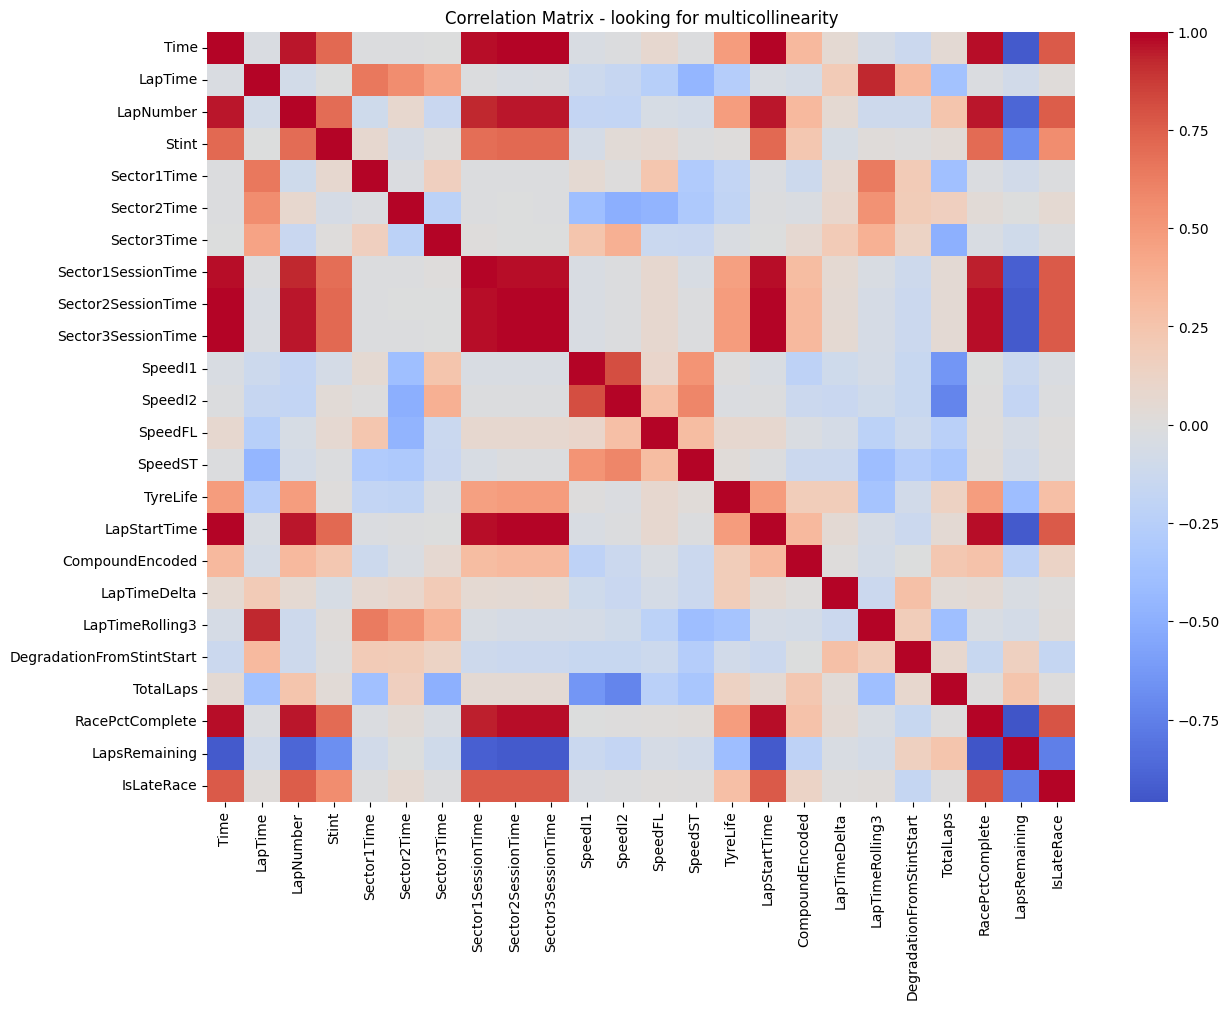

In [128]:
# Select only numeric cols for correlation check
numeric_cols = df.select_dtypes(include = [np.number]).columns.tolist()

# Remove the target variable 
numeric_cols = [col for col in numeric_cols if col != "Pitted"]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize = (14, 10))
sns.heatmap(corr_matrix, cmap = "coolwarm", center = 0, annot = False)
plt.title("Correlation Matrix - looking for multicollinearity")
plt.show()


In [130]:
# Find the pairs with correlation above 0.85 (high multicillinearity)

threshold = 0.85
high_corr_pair = []


for i in range(len(corr_matrix)):
    for j in range (i +1, len(corr_matrix)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > threshold:
            high_corr_pair.append((col1, col2, round (corr_val, 3)))


print("Highly correlated pairs (potential multicollinearity): ")
for pair in high_corr_pair:
    print(pair)

Highly correlated pairs (potential multicollinearity): 
('Time', 'LapNumber', np.float64(0.955))
('Time', 'Sector1SessionTime', np.float64(0.974))
('Time', 'Sector2SessionTime', np.float64(1.0))
('Time', 'Sector3SessionTime', np.float64(1.0))
('Time', 'LapStartTime', np.float64(1.0))
('Time', 'RacePctComplete', np.float64(0.971))
('Time', 'LapsRemaining', np.float64(-0.932))
('LapTime', 'LapTimeRolling3', np.float64(0.929))
('LapNumber', 'Sector1SessionTime', np.float64(0.929))
('LapNumber', 'Sector2SessionTime', np.float64(0.955))
('LapNumber', 'Sector3SessionTime', np.float64(0.955))
('LapNumber', 'LapStartTime', np.float64(0.955))
('LapNumber', 'RacePctComplete', np.float64(0.96))
('LapNumber', 'LapsRemaining', np.float64(-0.88))
('Sector1SessionTime', 'Sector2SessionTime', np.float64(0.974))
('Sector1SessionTime', 'Sector3SessionTime', np.float64(0.974))
('Sector1SessionTime', 'LapStartTime', np.float64(0.974))
('Sector1SessionTime', 'RacePctComplete', np.float64(0.944))
('Sector1S

#### Family 1: "Time": cols ( all measure the same thing : race progress)

Time, LapStartTime, Sector1/2/3SessionTime, LapNumber, RacePctComplete, LapsRemaining

Decision: we drop everything else but the Engineered features

In [136]:
cols_to_drop = [
    "Time", "LapStartTime",
    "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime",
    "LapNumber"]

df_logreg = df.drop(columns = cols_to_drop, errors = "ignore")
print("Dropped columns: ", cols_to_drop)
print("Remainign shape: ", df.logreg.shape)

Dropped columns:  ['Time', 'LapStartTime', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'LapNumber']
Remainign shape:  (11089, 28)


#### Family 2: LapTime vs LapTimeRolling3 (0.929)

Decision: Drop LapTime itself for logistic regresion, keep LapTimeRolling3, since it is the smoothed, less noisy version

In [138]:
df_logreg = df_logreg.drop(columns = ["LapTime"], errors = "ignore")

In [156]:
# Final Multicollinearity check 

numeric_cols_logreg = df_logreg.select_dtypes(include = [np.number]).columns.tolist()
numeric_cols_logreg = [col for col in numeric_cols_logreg if col != "Pitted"]

corr_matrix_final = df_logreg[numeric_cols_logreg].corr()

high_corr_remaining = []

for i in range(len(corr_matrix_final.columns)):
    for j in range(i+1, len(corr_matrix_final.columns)):
        corr_val = corr_matrix_final.iloc[i, j]
        if abs(corr_val) > 0.85:
            high_corr_remaining.append((
                corr_matrix_final.columns[i],
                corr_matrix_final.columns[j],
                round(corr_val, 3)

            ))

print("Remaining high correlation pairs: :", high_corr_remaining)
print("\nFinal shape for logistic regression: ", df_logreg.shape)

Remaining high correlation pairs: : [('RacePctComplete', 'LapsRemaining', np.float64(-0.959))]

Final shape for logistic regression:  (11089, 27)


---

#### Scaling/ Normalising features (for logistic regression)

- logistic regression uses gradient descent to learn, and it's sensitive to features being on different scales. A feature like LapTimeRolling3 (ranging ~85 - 110) would dominate over RacePctComplete (ranging 0-1) purely cause ot its bigger numbers, not becaus eof the significance
  

In [163]:
# Seperate features (X) from the target (y) for logreg dataset
# Exclude non-numeric / non-feature cols too

exclude_cols = ["Pitted", "Driver", "RaceName", "Compound"]

feature_cols_logreg = [col for col in df_logreg.columns if col not in exclude_cols]
feature_cols_logreg = df_logreg[feature_cols_logreg].select_dtypes(include = [np.number]).columns.tolist()

feature_cols_logreg




['Stint',
 'Sector1Time',
 'Sector2Time',
 'Sector3Time',
 'SpeedI1',
 'SpeedI2',
 'SpeedFL',
 'SpeedST',
 'TyreLife',
 'CompoundEncoded',
 'LapTimeDelta',
 'LapTimeRolling3',
 'DegradationFromStintStart',
 'TotalLaps',
 'RacePctComplete',
 'LapsRemaining',
 'IsLateRace']

In [165]:
print("Position" in df_logreg.columns)
print(df_logreg["Position"].dtype)

True
category


In [173]:
df_logreg["Position"] = df_logreg["Position"].astype(float)

In [181]:
# Remove IsLateRace from the scaling list

feature_cols_logreg = [col for col in feature_cols_logreg if col != "IsLateRace"]
for col in feature_cols_logreg:
    print(col)

Stint
Sector1Time
Sector2Time
Sector3Time
SpeedI1
SpeedI2
SpeedFL
SpeedST
TyreLife
Position
CompoundEncoded
LapTimeDelta
LapTimeRolling3
DegradationFromStintStart
TotalLaps
RacePctComplete
LapsRemaining


In [183]:
print("Position" in feature_cols_logreg)
print(df_logreg["Position"].dtype)

True
float64


In [185]:
print("Final columns to scale:", feature_cols_logreg)

Final columns to scale: ['Stint', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'TyreLife', 'Position', 'CompoundEncoded', 'LapTimeDelta', 'LapTimeRolling3', 'DegradationFromStintStart', 'TotalLaps', 'RacePctComplete', 'LapsRemaining']


In [187]:
# Applying the Scaler 

# creat the scaler
scaler = StandardScaler()

# Fit the transform ONLY the selected feature columns
df_logreg[feature_cols_logreg] = scaler.fit_transform(df_logreg[feature_cols_logreg])

# Check the result 
df_logreg[feature_cols_logreg].describe().T

,count,mean,std,min,25%,50%,75%,max
Stint,11089.0,4.100887e-17,1.000045,-1.160604,-1.160604,0.009497,1.179597,5.860001
Sector1Time,11089.0,-1.845399e-16,1.000045,-1.647054,-0.674477,0.140794,0.383392,7.071303
Sector2Time,11089.0,-6.151330e-17,1.000045,-2.353090,-0.657599,0.190548,0.720372,6.259030
Sector3Time,11089.0,-4.049626e-16,1.000045,-1.423370,-0.695249,-0.300966,0.437571,8.446537
SpeedI1,11089.0,2.460532e-16,1.000045,-3.839327,-0.579014,0.342868,0.590202,1.579539
SpeedI2,11089.0,5.946286e-16,1.000045,-3.974758,-0.426850,0.089209,0.820294,1.787905
SpeedFL,11089.0,-5.331153e-16,1.000045,-6.721656,-0.547619,-0.151424,0.740015,1.961615
SpeedST,11089.0,-9.226996e-17,1.000045,-8.285215,-0.345954,0.128032,0.523020,2.537459
TyreLife,11089.0,-5.382414e-17,1.000045,-1.338031,-0.762200,-0.186370,0.581404,3.844443
Position,11089.0,-9.611454e-17,1.000045,-1.628686,-0.896640,0.018418,0.933476,1.848534


In [191]:
# Save both versions

# for XGBoost
df.to_csv("../data/processed/features_2023.csv", index =False)
print(f"XGBoost dataset shape: {df.shape}")

XGBoost dataset shape: (11089, 34)


In [ ]:
# For Logistic Regression 
df_logreg.to_csv("../data/processed/features_